# The Complete 7-Attribute WLS Signature Prototype (Dark Theme + Thick Lines)
This notebook implements all 7 physical properties using a premium Dark Mode aesthetic with high-contrast, thick lines so the signals are completely clear and do not fade out.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob
import warnings
warnings.filterwarnings('ignore')

# --- PREMIUM DARK THEME ---
plt.style.use('dark_background')

# --- CONFIGURATION ---
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
LOOKBACK_SHORT = 13
LOOKBACK_LONG = 54
NORMALIZATION_WINDOW = 200
ACCEL_LOOKBACK = 3
PLOT_START = '2023-01-01'
PLOT_END = '2023-03-31'

WARMUP_DAYS = NORMALIZATION_WINDOW + LOOKBACK_LONG

In [2]:
# --- MATH FUNCTIONS ---
def calc_wls_full(series, window):
    reg_line_values = np.full(len(series), np.nan)
    slopes = np.full(len(series), np.nan)
    std_errors = np.full(len(series), np.nan)
    r_squared = np.full(len(series), np.nan)
    z_scores = np.full(len(series), np.nan)
    
    x = np.arange(window)
    w = np.arange(1, window + 1)
    sum_w = np.sum(w)
    
    for i in range(window - 1, len(series)):
        y = series.iloc[i - window + 1 : i + 1].values
        
        w_mean_x = np.sum(w * x) / sum_w
        w_mean_y = np.sum(w * y) / sum_w
        
        cov = np.sum(w * (x - w_mean_x) * (y - w_mean_y))
        var_x = np.sum(w * (x - w_mean_x)**2)
        
        slope = cov / var_x if var_x != 0 else 0
        intercept = w_mean_y - slope * w_mean_x
        
        predictions = slope * x + intercept
        residuals = y - predictions
        
        # MSE and Standard Error (Noise)
        mse = np.sum(w * residuals**2) / sum_w
        se = np.sqrt(mse)
        
        # R-Squared (Consistency)
        sst = np.sum(w * (y - w_mean_y)**2) / sum_w 
        r2 = 1 - (mse / sst) if sst != 0 else 0
        # Cap R2 between 0 and 1 strictly just in case of rounding errors
        r2 = max(0, min(1, r2))
        
        # Save Values
        reg_val = (slope * (window - 1)) + intercept
        reg_line_values[i] = reg_val
        slopes[i] = (slope / w_mean_y) * 252 * 100
        std_errors[i] = (se / w_mean_y) * 100
        r_squared[i] = r2
        
        # Z-Score (Extension): (Price Today - Line Today) / SE
        z_scores[i] = (y[-1] - reg_val) / se if se != 0 else 0
        
    return pd.Series(reg_line_values, index=series.index), \
           pd.Series(slopes, index=series.index), \
           pd.Series(std_errors, index=series.index), \
           pd.Series(r_squared, index=series.index), \
           pd.Series(z_scores, index=series.index)

def rolling_minmax(series, window):
    roll_min = series.rolling(window).min()
    roll_max = series.rolling(window).max()
    return ((series - roll_min) / (roll_max - roll_min)) * 100


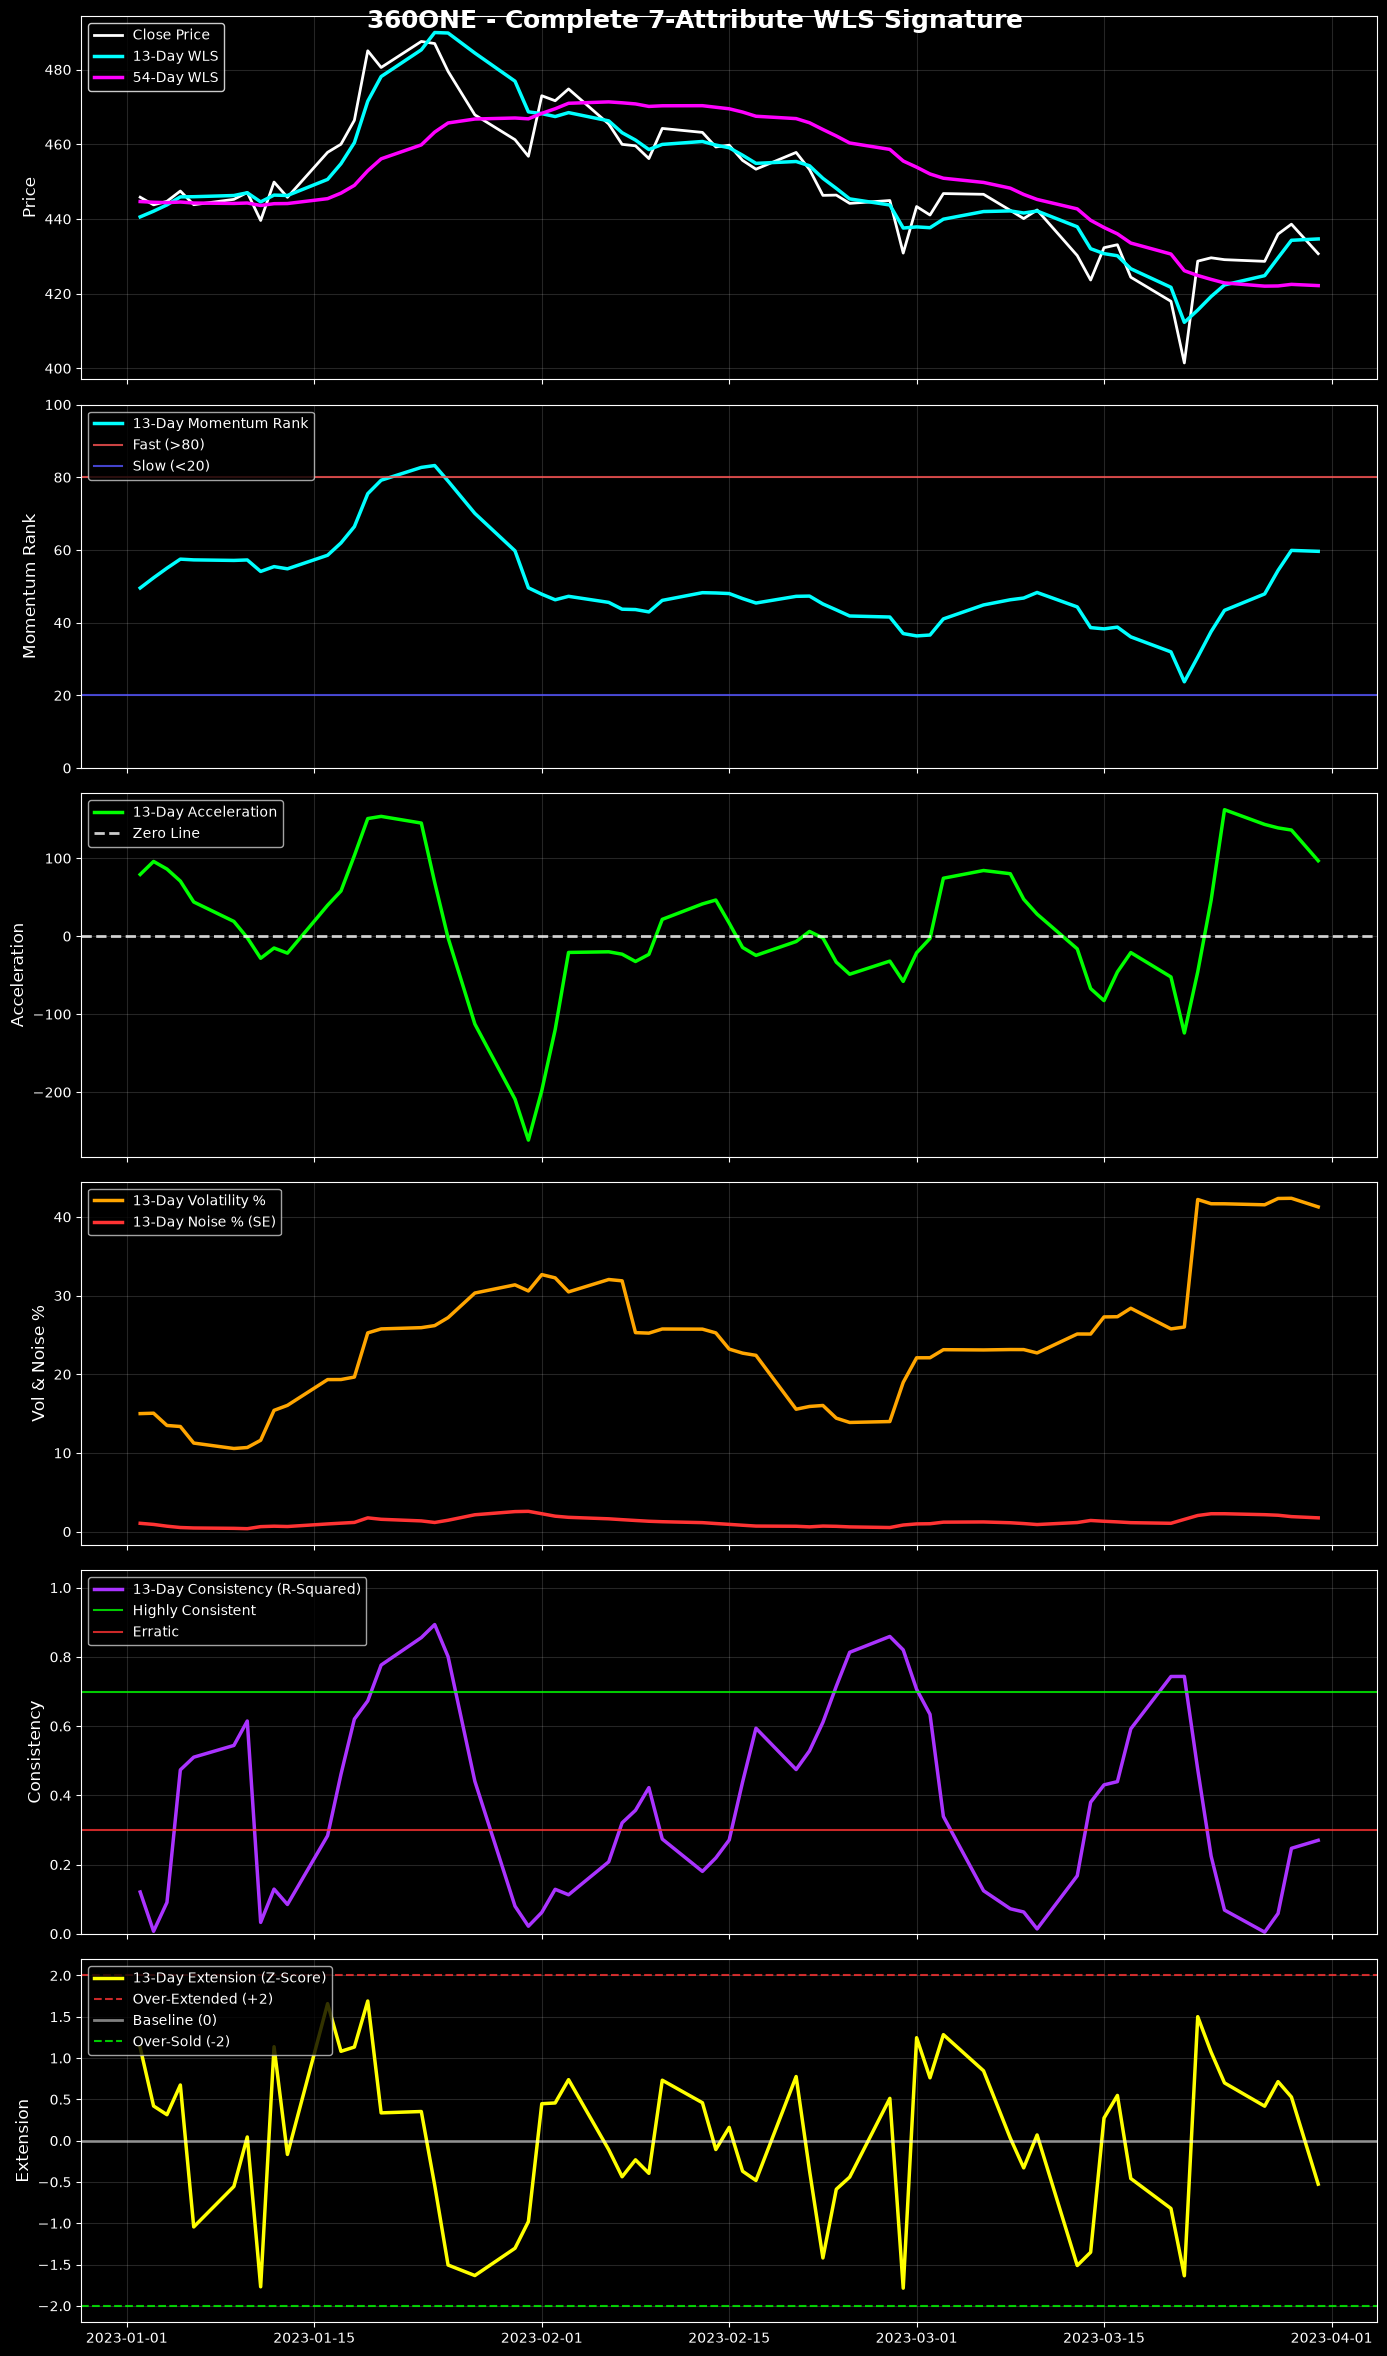

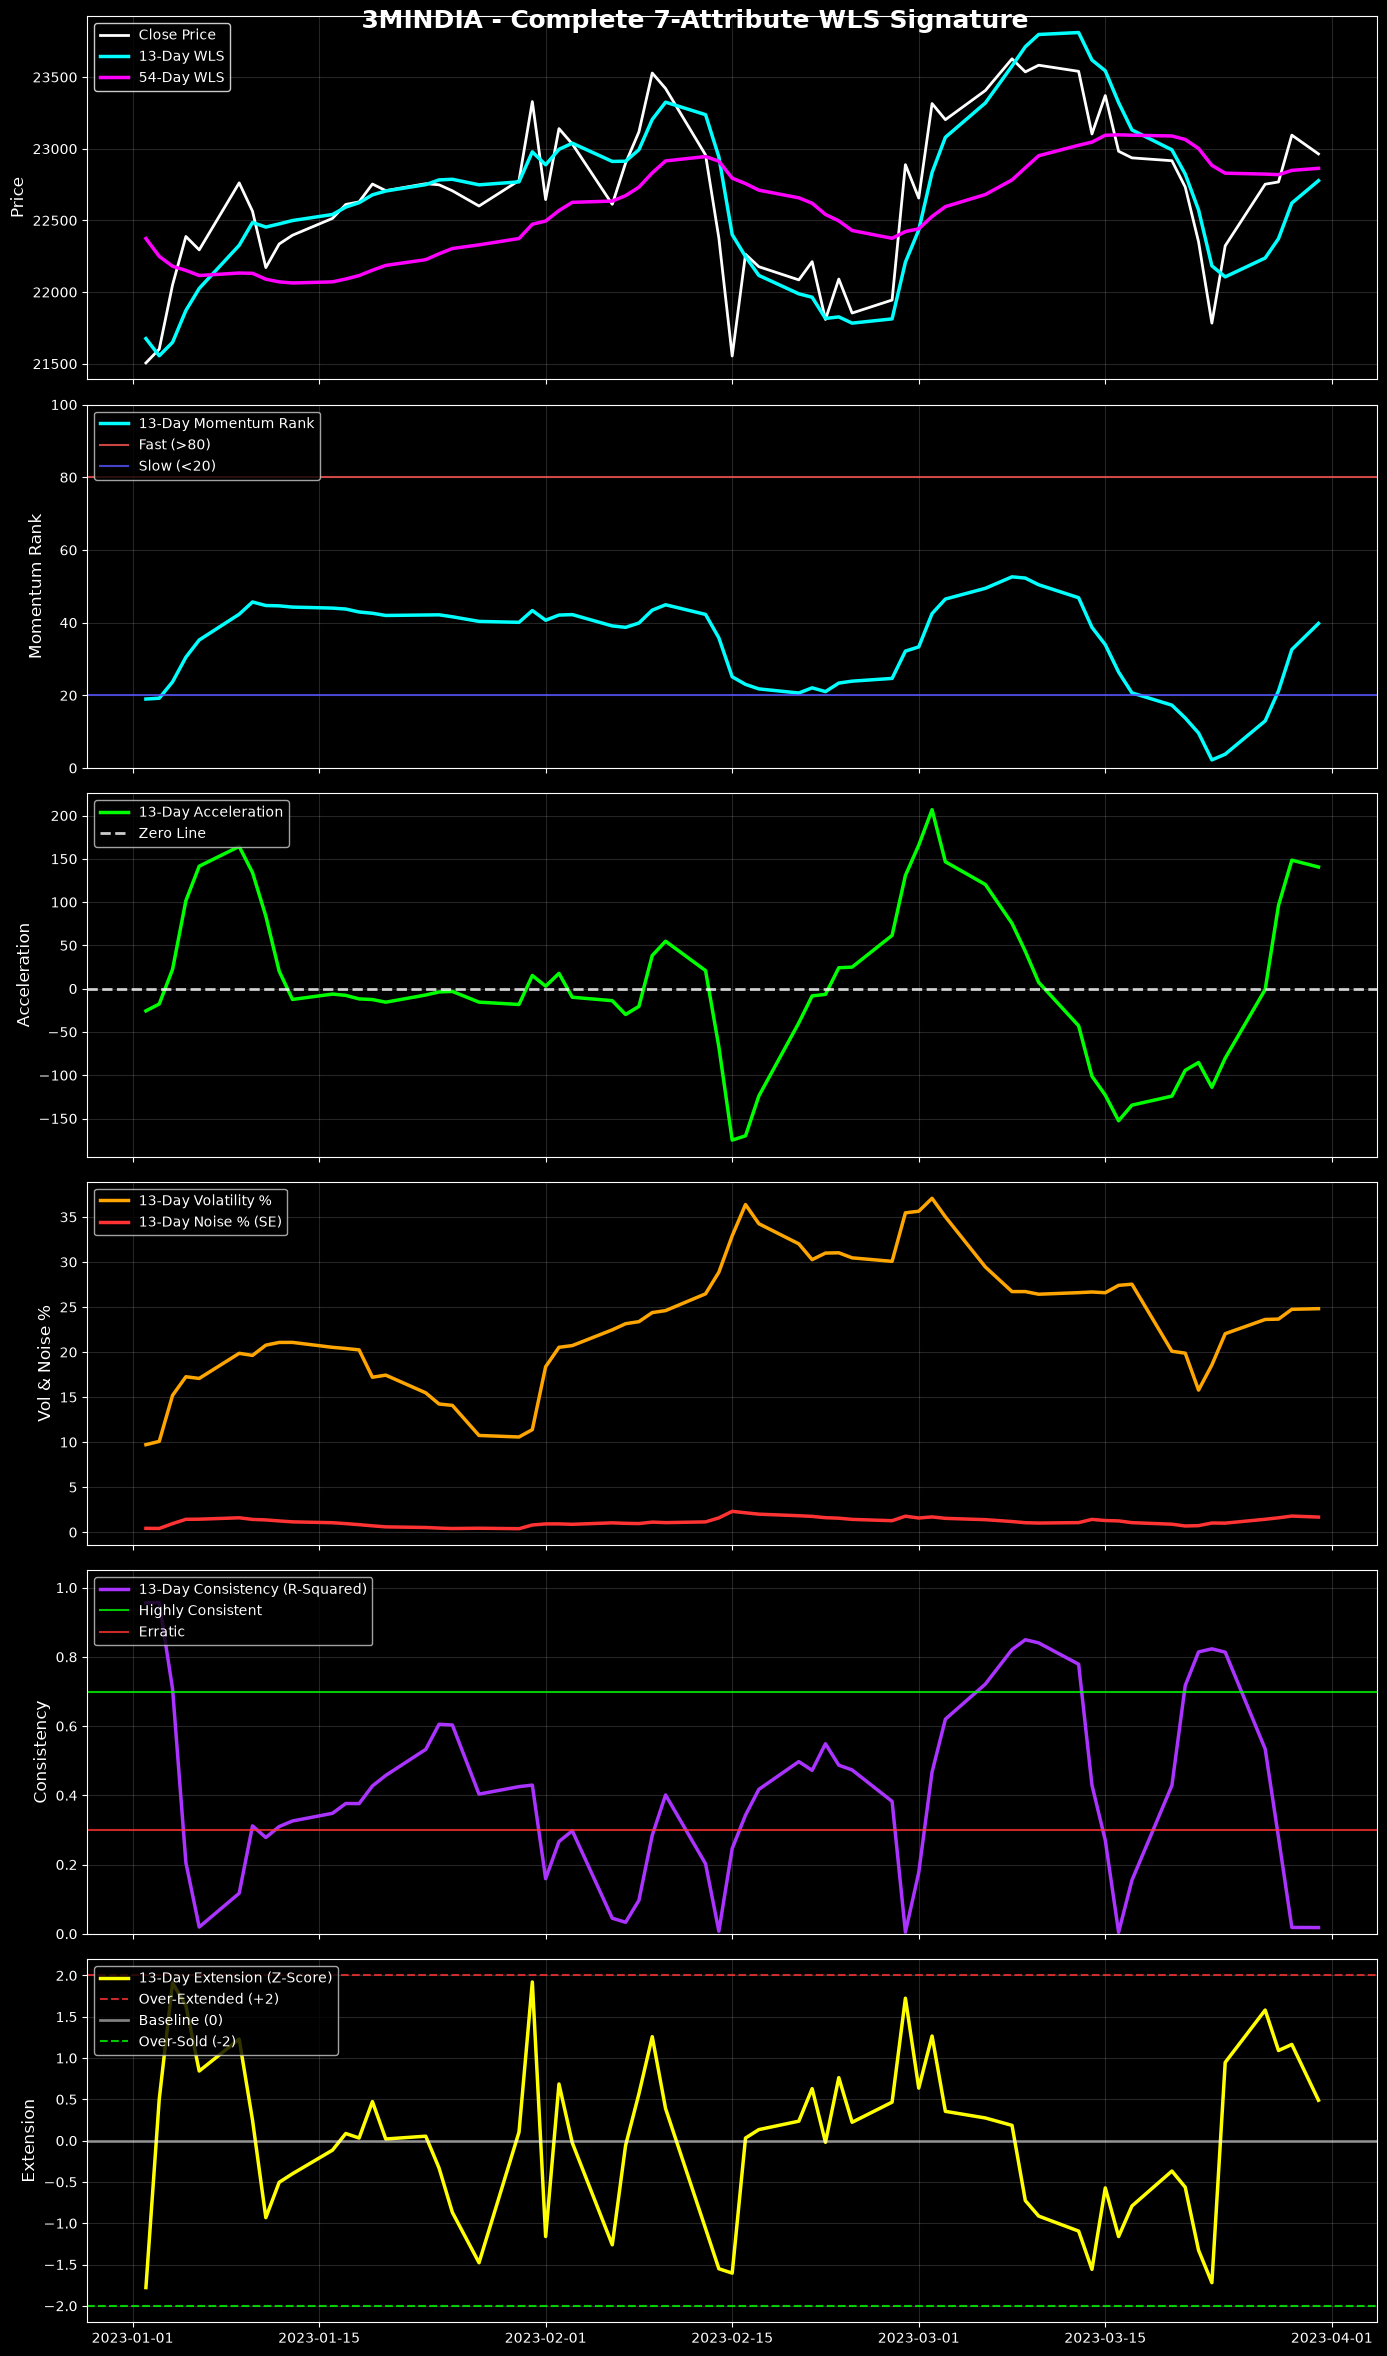

In [3]:
# --- PROCESSING & PLOTTING ---
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:3]

for file in all_files:
    stock_name = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    try:
        start_idx = df[df['Date'] >= PLOT_START].index[0]
        load_start_idx = max(0, start_idx - WARMUP_DAYS)
        end_idx = df[df['Date'] <= PLOT_END].index[-1]
    except IndexError:
        continue 
        
    df = df.iloc[load_start_idx:end_idx+1].copy()
    
    # 1. Full WLS Engine Extraction
    df['lr_13'], df['slope_13'], df['se_13'], df['r2_13'], df['z_13'] = calc_wls_full(df['Close'], LOOKBACK_SHORT)
    df['lr_54'], df['slope_54'], df['se_54'], df['r2_54'], df['z_54'] = calc_wls_full(df['Close'], LOOKBACK_LONG)
    
    # 2. Acceleration
    df['accel_13'] = df['slope_13'].diff(ACCEL_LOOKBACK)
    
    # 3. Normalized Slopes
    df['slope_13_norm'] = rolling_minmax(df['slope_13'], NORMALIZATION_WINDOW)
    
    # 4. Volatility %
    df['vol_13'] = df['Close'].pct_change().rolling(LOOKBACK_SHORT).std() * np.sqrt(252) * 100
    
    # Trim Warmup
    plot_df = df[df['Date'] >= PLOT_START].copy()
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(6, 1, figsize=(14, 24), sharex=True)
    fig.suptitle(f"{stock_name} - Complete 7-Attribute WLS Signature", fontsize=18, weight='bold', color='white')
    
    # Pane 1: Price and Regressions
    axes[0].plot(plot_df['Date'], plot_df['Close'], color='#FFFFFF', linewidth=2, label='Close Price')
    axes[0].plot(plot_df['Date'], plot_df['lr_13'], color='#00FFFF', linewidth=2.5, label='13-Day WLS')
    axes[0].plot(plot_df['Date'], plot_df['lr_54'], color='#FF00FF', linewidth=2.5, label='54-Day WLS')
    axes[0].set_ylabel("Price", fontsize=12)
    axes[0].legend(loc='upper left', frameon=True, facecolor='black', edgecolor='white')
    axes[0].grid(color='white', alpha=0.15)
    
    # Pane 2: Normalized Momentum (0-100)
    axes[1].plot(plot_df['Date'], plot_df['slope_13_norm'], color='#00FFFF', linewidth=2.5, label='13-Day Momentum Rank')
    axes[1].axhline(80, color='#FF5555', linestyle='-', linewidth=1.5, alpha=0.8, label='Fast (>80)')
    axes[1].axhline(20, color='#5555FF', linestyle='-', linewidth=1.5, alpha=0.8, label='Slow (<20)')
    axes[1].set_ylabel("Momentum Rank", fontsize=12)
    axes[1].set_ylim(0, 100)
    axes[1].legend(loc='upper left', frameon=True, facecolor='black')
    axes[1].grid(color='white', alpha=0.15)
    
    # Pane 3: Acceleration
    axes[2].plot(plot_df['Date'], plot_df['accel_13'], color='#00FF00', linewidth=2.5, label='13-Day Acceleration')
    axes[2].axhline(0, color='white', linestyle='--', linewidth=2, alpha=0.8, label='Zero Line')
    axes[2].set_ylabel("Acceleration", fontsize=12)
    axes[2].legend(loc='upper left', frameon=True, facecolor='black')
    axes[2].grid(color='white', alpha=0.15)
    
    # Pane 4: Volatility and Noise
    axes[3].plot(plot_df['Date'], plot_df['vol_13'], color='#FFA500', linewidth=2.5, label='13-Day Volatility %')
    axes[3].plot(plot_df['Date'], plot_df['se_13'], color='#FF3333', linewidth=2.5, label='13-Day Noise % (SE)')
    axes[3].set_ylabel("Vol & Noise %", fontsize=12)
    axes[3].legend(loc='upper left', frameon=True, facecolor='black')
    axes[3].grid(color='white', alpha=0.15)
    
    # Pane 5: Consistency (R-Squared)
    axes[4].plot(plot_df['Date'], plot_df['r2_13'], color='#AA33FF', linewidth=2.5, label='13-Day Consistency (R-Squared)')
    axes[4].axhline(0.7, color='#00FF00', linestyle='-', linewidth=1.5, alpha=0.8, label='Highly Consistent')
    axes[4].axhline(0.3, color='#FF3333', linestyle='-', linewidth=1.5, alpha=0.8, label='Erratic')
    axes[4].set_ylabel("Consistency", fontsize=12)
    axes[4].set_ylim(0, 1.05)
    axes[4].legend(loc='upper left', frameon=True, facecolor='black')
    axes[4].grid(color='white', alpha=0.15)
    
    # Pane 6: Extension (Z-Score)
    axes[5].plot(plot_df['Date'], plot_df['z_13'], color='#FFFF00', linewidth=2.5, label='13-Day Extension (Z-Score)')
    axes[5].axhline(2, color='#FF3333', linestyle='--', linewidth=1.5, alpha=0.8, label='Over-Extended (+2)')
    axes[5].axhline(0, color='white', linestyle='-', linewidth=2, alpha=0.5, label='Baseline (0)')
    axes[5].axhline(-2, color='#00FF00', linestyle='--', linewidth=1.5, alpha=0.8, label='Over-Sold (-2)')
    axes[5].set_ylabel("Extension", fontsize=12)
    axes[5].legend(loc='upper left', frameon=True, facecolor='black')
    axes[5].grid(color='white', alpha=0.15)
    
    plt.tight_layout()
    plt.show()
